In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

import pickle

In [2]:
train_df = pd.read_csv("/mnt/Basic\\x20data\\x20partition/linux files/AI 803/Datasets/ML Datasets/HR Analytics/archive/aug_train.csv")
test_df = pd.read_csv("/mnt/Basic\\x20data\\x20partition/linux files/AI 803/Datasets/ML Datasets/HR Analytics/archive/aug_test.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

print(train_df.head())

Training shape: (19158, 14)
Test shape: (2129, 13)
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline experience company_size    company_type last_new_job  \
0             STEM        >20          NaN             NaN            1   
1             STEM         15        50-99     

In [3]:
print(train_df.columns)

print("\nData information:")
train_df.info()

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='str')

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size 

In [4]:
print(train_df.isnull().sum())

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64


In [5]:
missing_values = train_df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
gender                 4508
enrolled_university     386
education_level         460
major_discipline       2813
experience               65
company_size           5938
company_type           6140
last_new_job            423
dtype: int64


In [6]:
print(train_df["target"].value_counts())

print("\nTarget percentages:")
print(train_df["target"].value_counts(normalize=True) * 100)

target
0.0    14381
1.0     4777
Name: count, dtype: int64

Target percentages:
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


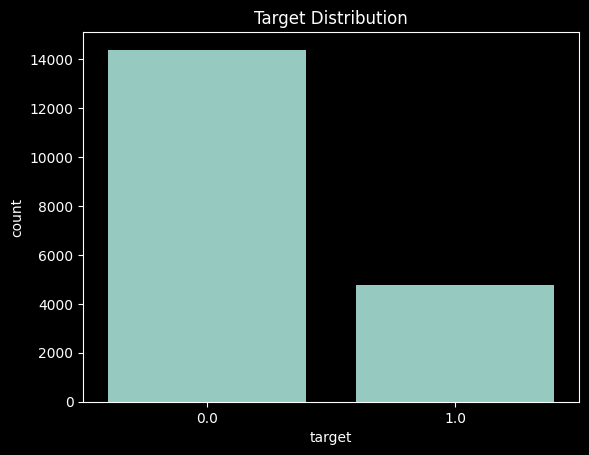

In [7]:
sns.countplot(x="target", data=train_df)
plt.title("Target Distribution")
plt.show()

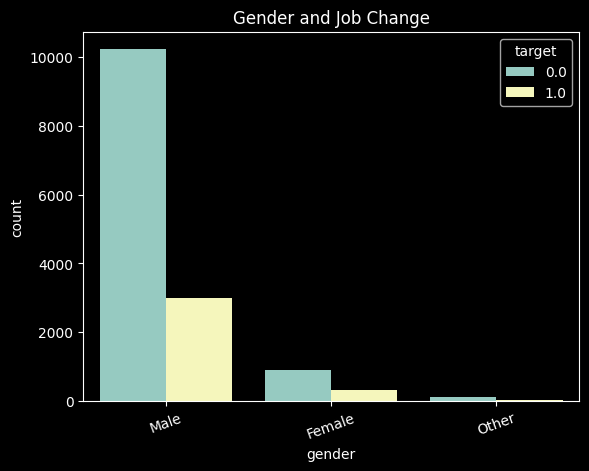

In [8]:
sns.countplot(x="gender", hue="target", data=train_df)
plt.title("Gender and Job Change")
plt.xticks(rotation=20)
plt.show()

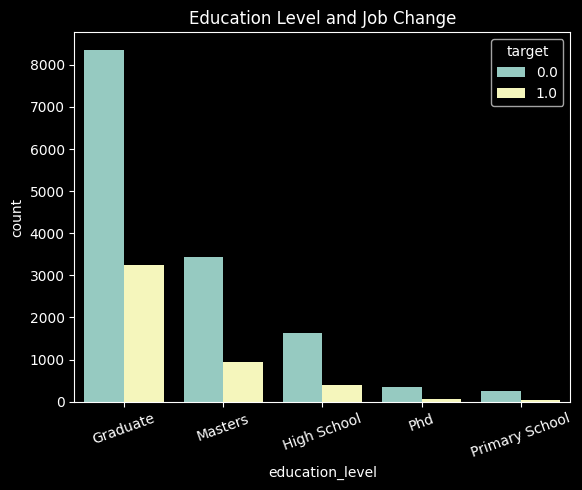

In [9]:
sns.countplot(x="education_level", hue="target", data=train_df)
plt.title("Education Level and Job Change")
plt.xticks(rotation=20)
plt.show()

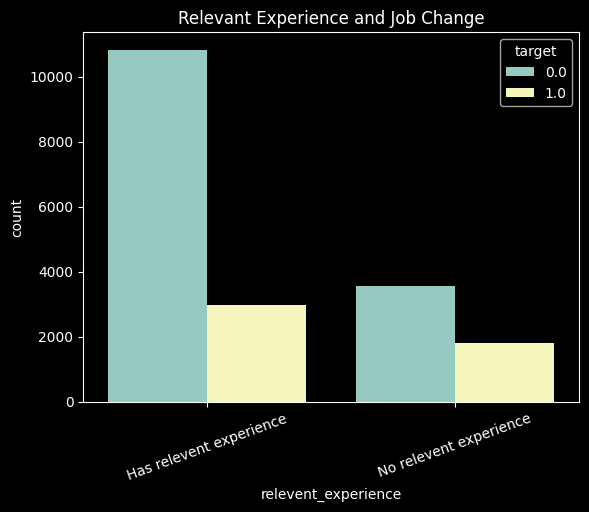

In [10]:
sns.countplot(x="relevent_experience", hue="target", data=train_df)
plt.title("Relevant Experience and Job Change")
plt.xticks(rotation=20)
plt.show()

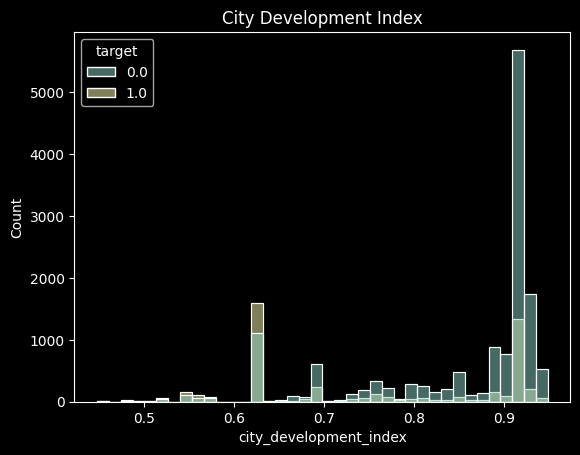

In [11]:
sns.histplot(data=train_df, x="city_development_index", hue="target")
plt.title("City Development Index")
plt.show()

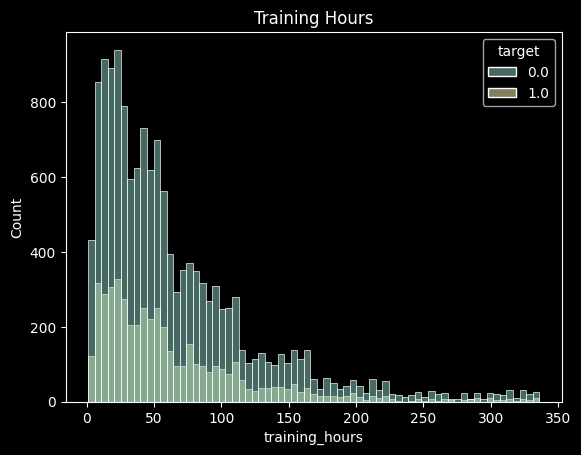

In [12]:
sns.histplot(data=train_df, x="training_hours", hue="target")
plt.title("Training Hours")
plt.show()

In [13]:
train = train_df.copy()
test = test_df.copy()

print("Training data:")
print(train.head())

print("\nTest data:")
print(test.head())

Training data:
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline experience company_size    company_type last_new_job  \
0             STEM        >20          NaN             NaN            1   
1             STEM         15        50-99         Pvt Ltd           >4   
2       

In [14]:
train["gender"] = train["gender"].fillna("Unknown")
test["gender"] = test["gender"].fillna("Unknown")

print(train[["gender"]].head())

    gender
0     Male
1     Male
2  Unknown
3  Unknown
4     Male


In [15]:
train["major_discipline"] = train["major_discipline"].fillna("Unknown")
test["major_discipline"] = test["major_discipline"].fillna("Unknown")

print(train[["major_discipline"]].head())

  major_discipline
0             STEM
1             STEM
2             STEM
3  Business Degree
4             STEM


In [16]:
train["company_type"] = train["company_type"].fillna("Unknown")
test["company_type"] = test["company_type"].fillna("Unknown")

print(train[["company_type"]].head())

     company_type
0         Unknown
1         Pvt Ltd
2         Unknown
3         Pvt Ltd
4  Funded Startup


In [17]:
train["company_size"] = train["company_size"].fillna("Unknown")
test["company_size"] = test["company_size"].fillna("Unknown")

print(train[["company_size"]].head())

  company_size
0      Unknown
1        50-99
2      Unknown
3      Unknown
4        50-99


In [18]:
train["enrolled_university"] = train["enrolled_university"].fillna("Unknown")
test["enrolled_university"] = test["enrolled_university"].fillna("Unknown")

print(train[["enrolled_university"]].head())

  enrolled_university
0       no_enrollment
1       no_enrollment
2    Full time course
3             Unknown
4       no_enrollment


In [19]:
train["education_level"] = train["education_level"].fillna("Unknown")
test["education_level"] = test["education_level"].fillna("Unknown")

print(train[["education_level"]].head())

  education_level
0        Graduate
1        Graduate
2        Graduate
3        Graduate
4         Masters


In [20]:
train["experience"] = train["experience"].replace("<1", "0")
train["experience"] = train["experience"].replace(">20", "21")

test["experience"] = test["experience"].replace("<1", "0")
test["experience"] = test["experience"].replace(">20", "21")

train["experience"] = pd.to_numeric(train["experience"], errors="coerce")
test["experience"] = pd.to_numeric(test["experience"], errors="coerce")

print(train[["experience"]].head())

   experience
0        21.0
1        15.0
2         5.0
3         0.0
4        21.0


In [21]:
experience_median = train["experience"].median()

train["experience"] = train["experience"].fillna(experience_median)
test["experience"] = test["experience"].fillna(experience_median)

print("Experience median:", experience_median)
print(train[["experience"]].head())

Experience median: 9.0
   experience
0        21.0
1        15.0
2         5.0
3         0.0
4        21.0


In [22]:
train["last_new_job"] = train["last_new_job"].replace("never", "0")
train["last_new_job"] = train["last_new_job"].replace(">4", "5")

test["last_new_job"] = test["last_new_job"].replace("never", "0")
test["last_new_job"] = test["last_new_job"].replace(">4", "5")

train["last_new_job"] = pd.to_numeric(train["last_new_job"], errors="coerce")
test["last_new_job"] = pd.to_numeric(test["last_new_job"], errors="coerce")

print(train[["last_new_job"]].head())

   last_new_job
0           1.0
1           5.0
2           0.0
3           0.0
4           4.0


In [23]:
last_job_median = train["last_new_job"].median()

train["last_new_job"] = train["last_new_job"].fillna(last_job_median)
test["last_new_job"] = test["last_new_job"].fillna(last_job_median)

print("Last new job median:", last_job_median)
print(train[["last_new_job"]].head())

Last new job median: 1.0
   last_new_job
0           1.0
1           5.0
2           0.0
3           0.0
4           4.0


In [24]:
test_ids = test["enrollee_id"].copy()

train = train.drop("enrollee_id", axis=1)
test = test.drop("enrollee_id", axis=1)

print("Training columns:")
print(train.columns)

Training columns:
Index(['city', 'city_development_index', 'gender', 'relevent_experience',
       'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_size', 'company_type', 'last_new_job',
       'training_hours', 'target'],
      dtype='str')


In [25]:
X = train.drop("target", axis=1)
y = train["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

X shape: (19158, 12)
y shape: (19158,)

X:
       city  city_development_index   gender      relevent_experience  \
0  city_103                   0.920     Male  Has relevent experience   
1   city_40                   0.776     Male   No relevent experience   
2   city_21                   0.624  Unknown   No relevent experience   
3  city_115                   0.789  Unknown   No relevent experience   
4  city_162                   0.767     Male  Has relevent experience   

  enrolled_university education_level major_discipline  experience  \
0       no_enrollment        Graduate             STEM        21.0   
1       no_enrollment        Graduate             STEM        15.0   
2    Full time course        Graduate             STEM         5.0   
3             Unknown        Graduate  Business Degree         0.0   
4       no_enrollment         Masters             STEM        21.0   

  company_size    company_type  last_new_job  training_hours  
0      Unknown         Unknown    

In [26]:
all_data = pd.concat([X, test], axis=0)

all_data = pd.get_dummies(all_data, drop_first=True)

print("Data after get_dummies:")
print(all_data.head())

print("\nNew shape:", all_data.shape)

Data after get_dummies:
   city_development_index  experience  last_new_job  training_hours  \
0                   0.920        21.0           1.0              36   
1                   0.776        15.0           5.0              47   
2                   0.624         5.0           0.0              83   
3                   0.789         0.0           0.0              52   
4                   0.767        21.0           4.0               8   

   city_city_10  city_city_100  city_city_101  city_city_102  city_city_103  \
0         False          False          False          False           True   
1         False          False          False          False          False   
2         False          False          False          False          False   
3         False          False          False          False          False   
4         False          False          False          False          False   

   city_city_104  ...  company_size_500-999  company_size_5000-9999  \
0  

In [27]:
X = all_data.iloc[:len(X), :]
test_encoded = all_data.iloc[len(X):, :]

print("X shape:", X.shape)
print("Test shape:", test_encoded.shape)

print("\nX head:")
print(X.head())

X shape: (19158, 158)
Test shape: (2129, 158)

X head:
   city_development_index  experience  last_new_job  training_hours  \
0                   0.920        21.0           1.0              36   
1                   0.776        15.0           5.0              47   
2                   0.624         5.0           0.0              83   
3                   0.789         0.0           0.0              52   
4                   0.767        21.0           4.0               8   

   city_city_10  city_city_100  city_city_101  city_city_102  city_city_103  \
0         False          False          False          False           True   
1         False          False          False          False          False   
2         False          False          False          False          False   
3         False          False          False          False          False   
4         False          False          False          False          False   

   city_city_104  ...  company_size_500-999

In [28]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in test:", test_encoded.isnull().sum().sum())

Missing values in X: 0
Missing values in test: 0


In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (15326, 158)
X_val: (3832, 158)
y_train: (15326,)
y_val: (3832,)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_encoded)

print("Scaling finished.")

Scaling finished.


In [31]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [32]:
logistic_pred = logistic_model.predict(X_val_scaled)

print("First predictions:")
print(logistic_pred[:20])

First predictions:
[0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1.]


In [33]:
logistic_accuracy = accuracy_score(y_val, logistic_pred)
logistic_precision = precision_score(y_val, logistic_pred)
logistic_recall = recall_score(y_val, logistic_pred)
logistic_f1 = f1_score(y_val, logistic_pred)

print("Logistic Regression Results")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1 Score:", logistic_f1)

Logistic Regression Results
Accuracy: 0.7711377870563675
Precision: 0.5276595744680851
Recall: 0.7790575916230367
F1 Score: 0.6291754756871036


In [34]:
print(classification_report(y_val, logistic_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.77      0.83      2877
         1.0       0.53      0.78      0.63       955

    accuracy                           0.77      3832
   macro avg       0.72      0.77      0.73      3832
weighted avg       0.82      0.77      0.78      3832



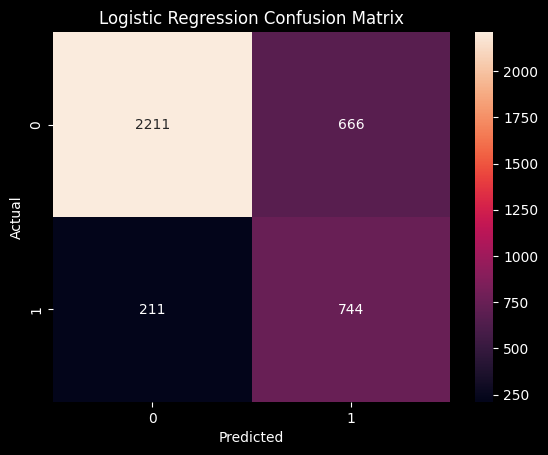

In [35]:
cm = confusion_matrix(y_val, logistic_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [37]:
rf_pred = random_forest.predict(X_val)

print("First predictions:")
print(rf_pred[:20])

First predictions:
[0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1.]


In [38]:
rf_accuracy = accuracy_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)
rf_f1 = f1_score(y_val, rf_pred)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest Results
Accuracy: 0.7847077244258872
Precision: 0.5826972010178118
Recall: 0.47958115183246075
F1 Score: 0.5261344055140724


In [39]:
print(classification_report(y_val, rf_pred))

              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      2877
         1.0       0.58      0.48      0.53       955

    accuracy                           0.78      3832
   macro avg       0.71      0.68      0.69      3832
weighted avg       0.77      0.78      0.78      3832



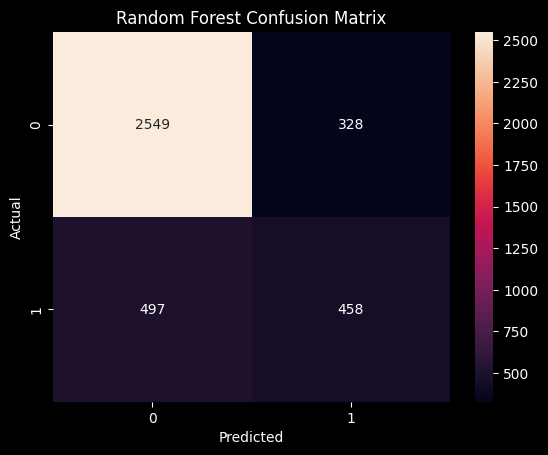

In [40]:
cm = confusion_matrix(y_val, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1 Score": [logistic_f1, rf_f1]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.771138   0.527660  0.779058  0.629175
1        Random Forest  0.784708   0.582697  0.479581  0.526134


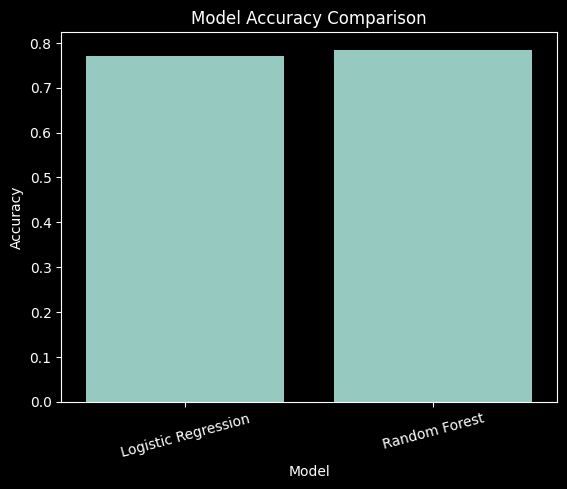

In [42]:
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

In [43]:
if rf_accuracy >= logistic_accuracy:
    final_model = random_forest
    final_model_name = "Random Forest"
    final_probability = random_forest.predict_proba(test_encoded)[:, 1]
else:
    final_model = logistic_model
    final_model_name = "Logistic Regression"
    final_probability = logistic_model.predict_proba(test_scaled)[:, 1]

print("Final model:", final_model_name)

Final model: Random Forest


In [44]:
ranking = pd.DataFrame()

ranking["enrollee_id"] = test_ids.values
ranking["job_change_probability"] = final_probability
ranking["stability_score"] = 1 - ranking["job_change_probability"]

ranking = ranking.sort_values(
    "stability_score",
    ascending=False
)

ranking = ranking.reset_index(drop=True)

print("Top 10 candidates:")
print(ranking.head(10))

Top 10 candidates:
   enrollee_id  job_change_probability  stability_score
0        31349                     0.0              1.0
1         9548                     0.0              1.0
2        19653                     0.0              1.0
3        19625                     0.0              1.0
4        23116                     0.0              1.0
5        27787                     0.0              1.0
6        15159                     0.0              1.0
7        31464                     0.0              1.0
8        22359                     0.0              1.0
9         4166                     0.0              1.0


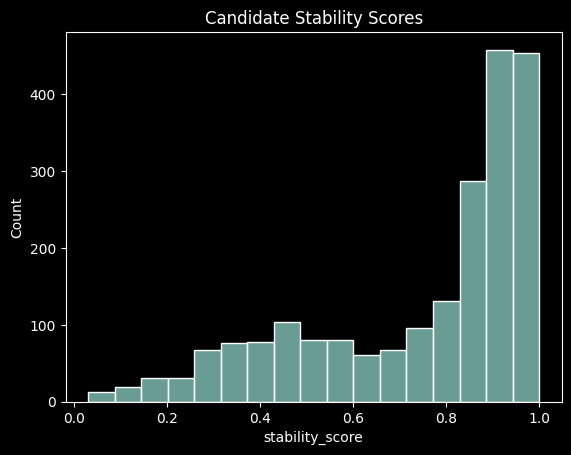

In [45]:
sns.histplot(ranking["stability_score"])
plt.title("Candidate Stability Scores")
plt.show()

In [46]:
pickle.dump(final_model, open("model.pkl", "wb"))

print("Model saved as model.pkl")

Model saved as model.pkl


In [47]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


In [48]:
import joblib

model_data = joblib.load('model.pkl')

joblib.dump(model_data, 'model.pkl', compress=3)

['model.pkl']